# 01 — Load and Inspect
Profiles the three raw datasets (incidents, neighbourhood boundaries, population) to surface data-quality issues and inform cleaning decisions in notebook 02. No transformations applied here; this notebook is read-only.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


### INCIDENTS FILE

In [2]:
# Load Incidents CSV file into dataframe
incidents_df = pd.read_csv('../data/raw/incidents.csv')


In [3]:
# Returns number of columns and rows
incidents_df.shape

(79039, 12)

In [4]:
# Returns column types and null/non-null counts
incidents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79039 entries, 0 to 79038
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Reported_Date          79039 non-null  object 
 1   Occurrence_Category    79039 non-null  object 
 2   Occurrence_Group       79039 non-null  object 
 3   Occurrence_Type_Group  79039 non-null  object 
 4   Intersection           79039 non-null  object 
 5   Reported_Day           79039 non-null  int64  
 6   Reported_Month         79039 non-null  int64  
 7   Reported_Year          79039 non-null  int64  
 8   OBJECTID               79039 non-null  int64  
 9   Date Reported          79039 non-null  object 
 10  x                      79039 non-null  float64
 11  y                      79039 non-null  float64
dtypes: float64(2), int64(4), object(6)
memory usage: 7.2+ MB


In [5]:
# Returns first 5 rows
incidents_df.head()

,Reported_Date,Occurrence_Category,Occurrence_Group,Occurrence_Type_Group,Intersection,Reported_Day,Reported_Month,Reported_Year,OBJECTID,Date Reported,x,y
0,7/6/2025 12:00:00 PM,Violent,Personal Violence,Assault,34 ST/KIRKNESS RD,6,7,2025,1,2025/07/06,-1.262292e+07,7.096520e+06
1,7/6/2025 12:00:00 PM,Disorder,Provincial Statute Violations,Intoxicated Person,92 AV/172 ST,6,7,2025,2,2025/07/06,-1.264787e+07,7.081139e+06
2,8/10/2025 12:00:00 PM,Disorder,Provincial Statute Violations,Intoxicated Person,132A AV/CLAREVIEW RD,10,8,2025,3,2025/08/10,-1.262190e+07,7.093501e+06
3,8/10/2025 12:00:00 PM,Disorder,Provincial Statute Violations,Intoxicated Person,12 AV/101 ST,10,8,2025,4,2025/08/10,-1.263356e+07,7.061652e+06
4,8/10/2025 12:00:00 PM,Violent,Personal Violence,Assault,SIR WINSTON CHURCHILL SQ/SIR WINSTON CHURCHILL SQ,10,8,2025,5,2025/08/10,-1.263372e+07,7.084339e+06


In [6]:
# Find total number of null values for each column
incidents_df.isnull().sum()

Reported_Date            0
Occurrence_Category      0
Occurrence_Group         0
Occurrence_Type_Group    0
Intersection             0
Reported_Day             0
Reported_Month           0
Reported_Year            0
OBJECTID                 0
Date Reported            0
x                        0
y                        0
dtype: int64

In [7]:
# Find count of occurrence categories
incidents_df['Occurrence_Category'].value_counts()

Occurrence_Category
Non-Violent    50916
Disorder       15872
Violent         7777
Traffic         2067
Weapons         1334
Drugs            990
Other             83
Name: count, dtype: int64

In [8]:
# Find count of occurrence groups
incidents_df['Occurrence_Group'].value_counts()

Occurrence_Group
Property                                              49128
Personal Violence                                      7612
Mischief/Graffiti                                      6602
General Disorder                                       6066
Disputes/Disturbances                                  2102
Criminal Flights/Impaired Operation/Escape Lawful      2067
Abandoned/Recovered/Seized Vehicles                    1528
Weapons Violations                                     1302
Provincial Statute Violations                          1189
Drug Violations                                         983
Counterfeiting/Gaming and Betting                       255
Sexual Violations                                       165
Explosives/Dangerous Goods                               32
Drug Violation                                            7
Workplace/Labour Violations                               1
Name: count, dtype: int64

In [9]:
# Find count of occurrence type groups
incidents_df['Occurrence_Type_Group'].value_counts()

Occurrence_Type_Group
Theft Under $5000              30856
Assault                         6365
Mischief - Property             6185
Theft of Motor Vehicle          3668
Trouble with Person             3662
Break and Enter Residential     3068
Fraud - Financial               2506
Break and Enter Commercial      2032
Theft Over $5000                1601
Internet Fraud                  1579
Impaired Driving                1573
Dispute                         1543
Trespassing                     1454
Recovered Motor Vehicle         1311
Fraud General                   1217
Possession Stolen Property      1170
Intoxicated Person              1102
Drugs                            990
Fraud Personal                   913
Robbery Personal                 849
Weapons Complaint                826
Suspicious Person                674
Disturbance                      559
Criminal Flight Event            494
Weapons Complaint Firearm        476
Fire Arson                       421
Robbery Commerci

In [10]:
# Summary statistics of crime date
incidents_df['Reported_Date'].describe()

count                     79039
unique                      364
top       6/10/2025 12:00:00 PM
freq                        327
Name: Reported_Date, dtype: object

In [11]:
# Summary statistics of crime date
incidents_df['Date Reported'].describe()

count          79039
unique           364
top       2025/06/10
freq             327
Name: Date Reported, dtype: object

In [12]:
# Summary statistic of x coordinate
incidents_df['x'].describe()

count    7.903900e+04
mean    -1.263506e+07
std      7.770899e+03
min     -1.265854e+07
25%     -1.263866e+07
50%     -1.263447e+07
75%     -1.262998e+07
max     -1.261222e+07
Name: x, dtype: float64

In [13]:
# Summary statistic of y coordinate
incidents_df['y'].describe()

count    7.903900e+04
mean     7.082341e+06
std      1.038606e+04
min      7.044886e+06
25%      7.075237e+06
50%      7.084079e+06
75%      7.089206e+06
max      7.116560e+06
Name: y, dtype: float64

### Neighbourhood File

In [14]:
# Load Neighbourhoods CSV file into dataframe
boundaries_df = gpd.read_file('../data/raw/neighbourhoods.geojson')

In [15]:
# Returns number of columns and rows
boundaries_df.shape

(407, 13)

In [16]:
# Returns column types and null/non-null counts
boundaries_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   :id                   407 non-null    object             
 1   :version              407 non-null    object             
 2   :created_at           407 non-null    datetime64[ms, UTC]
 3   :updated_at           407 non-null    datetime64[ms, UTC]
 4   name                  407 non-null    object             
 5   neighbourhood_number  407 non-null    object             
 6   descriptive_name      407 non-null    object             
 7   description           340 non-null    object             
 8   effective_start_date  407 non-null    datetime64[ms]     
 9   effective_end_date    0 non-null      object             
 10  civic_ward_name       407 non-null    object             
 11  district              407 non-null    object             
 12  

In [17]:
# Returns first 5 rows
boundaries_df.head()

,:id,:version,:created_at,:updated_at,name,neighbourhood_number,descriptive_name,description,effective_start_date,effective_end_date,civic_ward_name,district,geometry
0,row-pm4r-9h7d-wrqp,rv-9vmi_istq-mvck,2026-06-01 08:27:47.265000+00:00,2026-06-01 08:27:47.265000+00:00,ABBOTTSFIELD,2010,Abbottsfield,"Abbottsfield was once owned by E.F. Carey, one...",1981-10-01,None,Métis,North Central,"MULTIPOLYGON (((-113.38763 53.57613, -113.3888..."
1,row-ay9r.g3vt~8hyw,rv-rpy7.fh4f~rgkj,2026-06-01 08:27:47.265000+00:00,2026-06-01 08:27:47.265000+00:00,ALBANY,3460,Albany,None,2011-06-13,None,Anirniq,Northwest,"MULTIPOLYGON (((-113.56025 53.6316, -113.56227..."
2,row-sghk-q72y_d58w,rv-479x~9wxk.w8ep,2026-06-01 08:27:47.265000+00:00,2026-06-01 08:27:47.265000+00:00,ALBERTA AVENUE,1010,Alberta Avenue,One of the city's older residential neighbourh...,1981-10-01,None,Métis,North Central,"MULTIPOLYGON (((-113.49226 53.57662, -113.4922..."
3,row-adjc-8th5.fn3c,rv-2qkp.3uec_th6d,2026-06-01 08:27:47.265000+00:00,2026-06-01 08:27:47.265000+00:00,ALBERTA PARK INDUSTRIAL,4010,Alberta Park Industrial,This non-residential neighbourhood is largely ...,1981-10-01,None,Nakota Isga,Jasper Place,"MULTIPOLYGON (((-113.59041 53.56654, -113.5904..."
4,row-xmqy_zdjk_9hst,rv-y7dh.6fyn_scqj,2026-06-01 08:27:47.265000+00:00,2026-06-01 08:27:47.265000+00:00,ALCES,6669,Alces,Formerly Decoteau North,2019-07-25,None,Sspomitapi,Ellerslie,"MULTIPOLYGON (((-113.37649 53.42488, -113.3690..."


In [18]:
# Find total number of null values for each column
boundaries_df.isnull().sum()

:id                       0
:version                  0
:created_at               0
:updated_at               0
name                      0
neighbourhood_number      0
descriptive_name          0
description              67
effective_start_date      0
effective_end_date      407
civic_ward_name           0
district                  0
geometry                  0
dtype: int64

In [19]:
# File uses EPSG:4326, which mismatches the incidents file's EPSG:3857
boundaries_df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

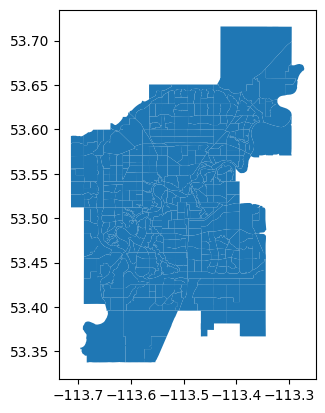

In [20]:
#  Visual sanity check (.plot()) confirms a recognisable Edmonton shape — geometries are intact
boundaries_df.plot()

### POPULATION FILE

In [21]:
population_df = pd.read_csv('../data/raw/population.csv')

In [22]:
# Returns number of rows and columns
population_df.shape

(388, 22)

In [23]:
# Returns column null-count and type
population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Ward                  388 non-null    object
 1   Neighbourhood Number  388 non-null    int64 
 2   Neighbourhood Name    388 non-null    object
 3   0 - 4                 388 non-null    object
 4   5 - 9                 388 non-null    object
 5   10 - 14               388 non-null    int64 
 6   15 - 19               388 non-null    int64 
 7   20 - 24               388 non-null    object
 8   25 - 29               388 non-null    object
 9   30 - 34               388 non-null    object
 10  35 - 39               388 non-null    object
 11  40 - 44               388 non-null    int64 
 12  45 - 49               388 non-null    int64 
 13  50 - 54               388 non-null    int64 
 14  55 - 59               388 non-null    int64 
 15  60 - 64               388 non-null    in

In [24]:
# Displays first 5 rows
population_df.head()

,Ward,Neighbourhood Number,Neighbourhood Name,0 - 4,5 - 9,10 - 14,15 - 19,20 - 24,25 - 29,30 - 34,...,45 - 49,50 - 54,55 - 59,60 - 64,65 - 69,70 - 74,75 - 79,80 - 84,85+,No Response
0,WARD 1,3140,CRESTWOOD,68,83,97,99,76,62,59,...,110,116,148,98,100,91,80,64,49,800
1,WARD 1,3330,PARKVIEW,126,162,138,165,155,96,128,...,164,218,247,197,146,89,90,82,64,705
2,WARD 11,6110,CPR IRVINE,0,1,0,0,18,44,39,...,1,6,1,0,1,0,0,2,0,48
3,WARD 9,5350,RHATIGAN RIDGE,73,130,117,112,112,84,56,...,103,142,185,205,171,102,74,42,39,"1,140"
4,WARD 5,4140,ELMWOOD,131,121,130,169,180,185,173,...,154,161,133,145,140,92,117,60,51,290


In [25]:
# Find number of null values
population_df.isnull().sum()

Ward                    0
Neighbourhood Number    0
Neighbourhood Name      0
0 - 4                   0
5 - 9                   0
10 - 14                 0
15 - 19                 0
20 - 24                 0
25 - 29                 0
30 - 34                 0
35 - 39                 0
40 - 44                 0
45 - 49                 0
50 - 54                 0
55 - 59                 0
60 - 64                 0
65 - 69                 0
70 - 74                 0
75 - 79                 0
80 - 84                 0
85+                     0
No Response             0
dtype: int64

In [26]:
# Find each column name
print(population_df.columns.tolist())

['Ward', 'Neighbourhood Number', 'Neighbourhood Name', '0 - 4', '5 - 9', '10 - 14', '15 - 19', '20 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44', '45 - 49', '50 - 54', '55 - 59', '60 - 64', '65 - 69', '70 - 74', '75 - 79', '80 - 84', '85+', 'No Response']


In [27]:
# Check to see if each neighbourhood corresponds to one row
population_df['Neighbourhood Name'].nunique()


388

In [28]:
print(len(population_df))

388


In [29]:
# Check datatypes
population_df.dtypes

Ward                    object
Neighbourhood Number     int64
Neighbourhood Name      object
0 - 4                   object
5 - 9                   object
10 - 14                  int64
15 - 19                  int64
20 - 24                 object
25 - 29                 object
30 - 34                 object
35 - 39                 object
40 - 44                  int64
45 - 49                  int64
50 - 54                  int64
55 - 59                  int64
60 - 64                  int64
65 - 69                  int64
70 - 74                  int64
75 - 79                  int64
80 - 84                  int64
85+                      int64
No Response             object
dtype: object

In [31]:
# Find values in population columns which are not null and can be parsed into numeric type
age_cols = [
    '0 - 4', '5 - 9', '10 - 14', '15 - 19', '20 - 24',
    '25 - 29', '30 - 34', '35 - 39', '40 - 44', '45 - 49',
    '50 - 54', '55 - 59', '60 - 64', '65 - 69', '70 - 74',
    '75 - 79', '80 - 84', '85+', 'No Response'
]

for col in age_cols:
    if population_df[col].dtype == 'object':
        # Try to convert; flag anything that fails
        non_numeric = population_df[col][pd.to_numeric(population_df[col], errors='coerce').isnull() & population_df[col].notnull()]
        if len(non_numeric) > 0:
            print(f"\n{col}: {len(non_numeric)} non-numeric values")
            print(f"  Unique non-numeric values: {non_numeric.unique()}")


0 - 4: 1 non-numeric values
  Unique non-numeric values: ['1,024']

5 - 9: 1 non-numeric values
  Unique non-numeric values: ['1,017']

20 - 24: 2 non-numeric values
  Unique non-numeric values: ['1,106' '2,084']

25 - 29: 3 non-numeric values
  Unique non-numeric values: ['1,837' '1,737' '1,713']

30 - 34: 4 non-numeric values
  Unique non-numeric values: ['1,305' '1,388' '1,077' '1,505']

35 - 39: 2 non-numeric values
  Unique non-numeric values: ['1,220' '1,074']

No Response: 75 non-numeric values
  Unique non-numeric values: ['1,140' '1,263' '1,968' '1,455' '1,045' '4,355' '1,314' '2,301' '1,370'
 '1,475' '5,173' '2,031' '1,226' '1,579' '1,041' '1,160' '1,332' '3,062'
 '1,762' '1,442' '1,502' '1,178' '1,040' '1,251' '1,154' '1,510' '1,029'
 '1,252' '1,432' '1,428' '1,006' '2,677' '1,075' '1,257' '1,036' '1,082'
 '1,412' '1,228' '1,268' '1,290' '2,958' '1,664' '2,537' '1,422' '2,093'
 '1,129' '1,105' '2,060' '1,151' '1,085' '1,137' '1,878' '3,266' '1,865'
 '1,210' '1,597' '1,415' 

In [32]:
# Strip commas, convert to numeric, sum.
city_total = population_df[age_cols].replace(',', '', regex=True).apply(pd.to_numeric).sum().sum()
print(f"City-wide total population: {city_total:,}")

City-wide total population: 899,138
